# 01. EDA e Pré-processamento

## Objetivo

Antes de aplicar qualquer técnica de Machine Learning, é preciso entender bem o problema e conhecer os dados.

## Contexto do problema

O objetivo aqui é prever a categoria de um produto a partir da sua descrição em texto. A variável que queremos prever, o target, é a coluna `categoria`, que tem mais de duas classes possíveis. Para fazer essa previsão contamos apenas com o texto da descrição do produto, na coluna `texto`.

In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from preprocessing import carregar_e_limpar

import warnings
warnings.filterwarnings('ignore')

## 2. Carregamento

In [2]:
df_bruto = pd.read_csv('../data/raw/dataset_ecommerce.csv')
print(f"Shape original: {df_bruto.shape}")
df_bruto.head()

Shape original: (50425, 2)


,categoria,texto
0,Household,Paper Plane Design Framed Wall Hanging Motivat...
1,Household,"SAF 'Floral' Framed Painting (Wood, 30 inch x ..."
2,Household,SAF 'UV Textured Modern Art Print Framed' Pain...
3,Household,"SAF Flower Print Framed Painting (Synthetic, 1..."
4,Household,Incredible Gifts India Wooden Happy Birthday U...


## 3. Qualidade dos dados

In [3]:
df_bruto.info()

<class 'pandas.DataFrame'>
RangeIndex: 50425 entries, 0 to 50424
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   categoria  50425 non-null  str  
 1   texto      50424 non-null  str  
dtypes: str(2)
memory usage: 788.0 KB


In [4]:
print("Valores nulos por coluna:")
print(df_bruto.isna().sum())
print(f"\nLinhas totalmente duplicadas: {df_bruto.duplicated().sum()}")
print(f"Descrições de texto duplicadas: {df_bruto['texto'].duplicated().sum()}")
print(f"Textos vazios (string vazia após strip): {(df_bruto['texto'].astype(str).str.strip() == '').sum()}")
print(f"\nCategorias únicas antes da limpeza: {sorted(df_bruto['categoria'].dropna().unique())}")

Valores nulos por coluna:
categoria    0
texto        1
dtype: int64

Linhas totalmente duplicadas: 22622
Descrições de texto duplicadas: 22622
Textos vazios (string vazia após strip): 0

Categorias únicas antes da limpeza: ['Books', 'Clothing & Accessories', 'Electronics', 'Household']


## 4. Limpeza

A limpeza remove os registros com valores nulos, padroniza o nome da categoria `Clothing & Accessories` e tira espaços em branco extras. Ela também remove duplicatas exatas de texto e categoria, pelo motivo explicado logo abaixo.

In [5]:
df_sem_dedup = carregar_e_limpar('../data/raw/dataset_ecommerce.csv', remover_duplicatas=False)
df = carregar_e_limpar('../data/raw/dataset_ecommerce.csv')

n_nulos_removidos = df_bruto.shape[0] - df_sem_dedup.shape[0]
n_duplicatas_removidas = df_sem_dedup.shape[0] - df.shape[0]

print(f"Shape original: {df_bruto.shape}")
print(f"Após remover nulos: {df_sem_dedup.shape} (-{n_nulos_removidos} linha(s) com valores nulos)")
print(f"Shape após limpeza completa: {df.shape} (-{n_duplicatas_removidas} linha(s) duplicada(s) de texto+categoria)")
print(f"Categorias após padronização: {sorted(df['categoria'].unique())}")
df.head()

Shape original: (50425, 2)
Após remover nulos: (50424, 2) (-1 linha(s) com valores nulos)
Shape após limpeza completa: (27802, 2) (-22622 linha(s) duplicada(s) de texto+categoria)
Categorias após padronização: ['Books', 'Clothing_Accessories', 'Electronics', 'Household']


,texto,categoria
0,Paper Plane Design Framed Wall Hanging Motivat...,Household
1,"SAF 'Floral' Framed Painting (Wood, 30 inch x ...",Household
2,SAF 'UV Textured Modern Art Print Framed' Pain...,Household
3,"SAF Flower Print Framed Painting (Synthetic, 1...",Household
4,Incredible Gifts India Wooden Happy Birthday U...,Household


### Removendo duplicatas

As duplicatas encontradas na seção anterior são linhas com texto e categoria idênticos, provavelmente o mesmo produto reaparecendo no catálogo (revenda, variações de cor ou tamanho com a mesma descrição, etc.). O risco é o `train_test_split` da seção 8 colocar cópias do mesmo texto dos dois lados, uma no treino e outra no teste. Nesse caso o modelo não estaria sendo avaliado em texto novo, estaria só reconhecendo algo que já viu, o que infla as métricas sem representar a capacidade real de generalização.

Para medir o tamanho do problema, refazemos a mesma divisão treino/teste da seção 8, mas sobre os dados sem deduplicar, e contamos quantas linhas do teste têm uma cópia idêntica (mesmo texto e mesma categoria) no treino.

In [6]:
idx_sem_dedup = np.arange(len(df_sem_dedup))
y_sem_dedup = LabelEncoder().fit_transform(df_sem_dedup['categoria'])
idx_tr_sd, idx_te_sd = train_test_split(
    idx_sem_dedup, test_size=0.2, random_state=42, stratify=y_sem_dedup
)

chave = df_sem_dedup['texto'] + '||' + df_sem_dedup['categoria']
em_treino = set(chave.iloc[idx_tr_sd])
teste_com_gemeo_no_treino = chave.iloc[idx_te_sd].isin(em_treino).sum()

print(f"Sem remover duplicatas, {teste_com_gemeo_no_treino} das {len(idx_te_sd)} linhas de teste "
      f"({teste_com_gemeo_no_treino / len(idx_te_sd) * 100:.1f}%) teriam uma cópia idêntica no treino.")
print("Por isso a limpeza deste projeto remove as duplicatas antes de qualquer split.")

Sem remover duplicatas, 6414 das 10085 linhas de teste (63.6%) teriam uma cópia idêntica no treino.
Por isso a limpeza deste projeto remove as duplicatas antes de qualquer split.


## 5. Distribuição das categorias

,quantidade,percentual (%)
categoria,,
Household,10564,38.0
Books,6256,22.5
Clothing_Accessories,5674,20.4
Electronics,5308,19.1


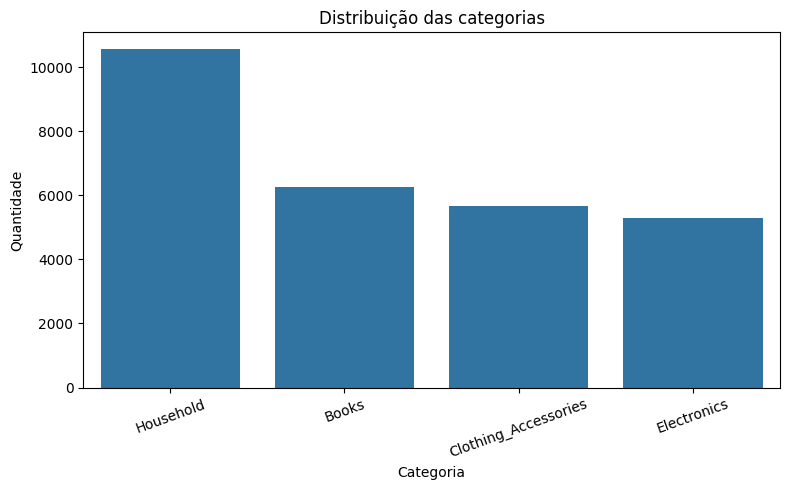

Razão entre a maior e a menor classe: 2.0x


In [7]:
contagem = df['categoria'].value_counts()
percentual = (contagem / len(df) * 100).round(1)

resumo_categorias = pd.DataFrame({'quantidade': contagem, 'percentual (%)': percentual})
display(resumo_categorias)

plt.figure(figsize=(8, 5))
sns.barplot(x=contagem.index, y=contagem.values, order=contagem.index)
plt.title('Distribuição das categorias')
plt.ylabel('Quantidade')
plt.xlabel('Categoria')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

razao_desbalanceamento = contagem.max() / contagem.min()
print(f"Razão entre a maior e a menor classe: {razao_desbalanceamento:.1f}x")

## 6. Análise do texto

,tamanho_texto,n_palavras
count,27802.000000,27802.000000
mean,699.997051,111.887094
std,1023.025018,166.116396
min,4.000000,1.000000
25%,215.000000,34.000000
50%,473.000000,76.000000
75%,916.750000,146.000000
max,50403.000000,8181.000000


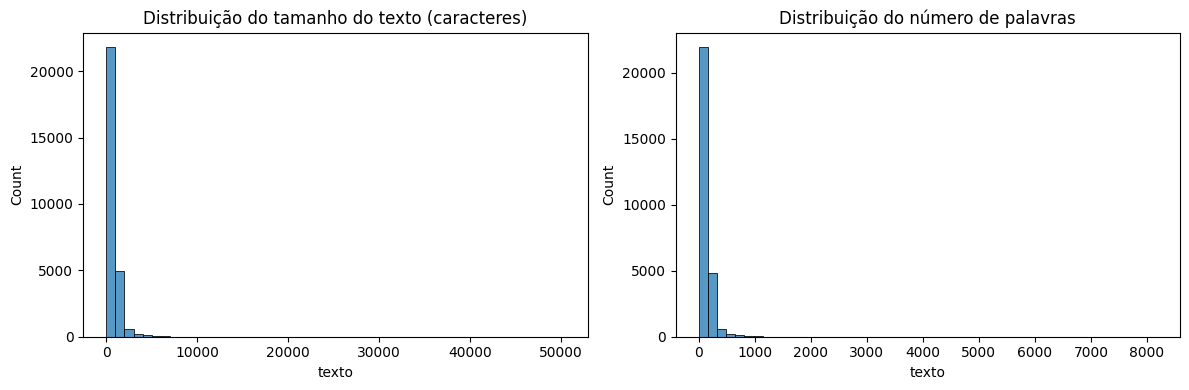

Texto mais curto: Yes!

Texto mais longo (300 primeiros caracteres): Risk Savvy: How to Make Good Decisions About the Author Gerd Gigerenzer is the author of Gut Feelings. He is currently the director of the Max Planck Institute for Human Development in Berlin, Germany, and lectures around the world on the importance of proper risk education for everyone from school-


In [8]:
tamanho_texto = df['texto'].str.len()
n_palavras = df['texto'].str.split().str.len()

display(pd.DataFrame({'tamanho_texto': tamanho_texto, 'n_palavras': n_palavras}).describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(tamanho_texto, bins=50, ax=axes[0])
axes[0].set_title('Distribuição do tamanho do texto (caracteres)')
sns.histplot(n_palavras, bins=50, ax=axes[1])
axes[1].set_title('Distribuição do número de palavras')
plt.tight_layout()
plt.show()

print("Texto mais curto:", df.loc[tamanho_texto.idxmin(), 'texto'])
print("\nTexto mais longo (300 primeiros caracteres):", df.loc[tamanho_texto.idxmax(), 'texto'][:300])

In [9]:
print("Exemplo de texto por categoria:")
for cat in sorted(df['categoria'].unique()):
    exemplo = df[df['categoria'] == cat]['texto'].iloc[0]
    print(f"\n[{cat}] {exemplo[:200]}...")

Exemplo de texto por categoria:

[Books] Inner Engineering: A Yogi's Guide to Joy About the Author Sadhguru Jaggi VasudevSADHGURU is a yogi, mystic, and visionary who established the Isha Foundation, a nonprofit dedicated to the cultivation ...

[Clothing_Accessories] Woopower 36M Pink for 024M Baby Trouser Top Sets3Pcs Boy Girl Hooded Topsstriped Pantshairband Outfits36Mpink Size name36m colourpink description100 brand new and type children setgender unisexfor sea...

[Electronics] Dell 19.5V-3.34AMP 65W Laptop Adapter (Without power Cord) Design Features of Dell Laptop - Power adapter - 65 Watt (No Power Cable) The Dell 65-Watt Inspiron AC Power Adapter helps you to charge Dell...

[Household] Paper Plane Design Framed Wall Hanging Motivational Office Decor Art Prints (8.7 X 8.7 inch) - Set of 4 Painting made up in synthetic frame with uv textured print which gives multi effects and attract...


## 7. Encoding do target

Como o modelo não entende texto diretamente, é preciso transformar a categoria em números. O `LabelEncoder` faz isso da forma mais simples: atribui um único número inteiro para cada categoria (0, 1, 2, 3...). 

Existe também o one-hot encoding, feito com `pd.get_dummies`, que cria uma coluna binária para cada categoria. Essa abordagem é mais indicada quando a variável categórica é usada como feature de entrada, por exemplo em um modelo linear, porque evita sugerir uma ordem ou escala entre categorias que na verdade não existe.

Neste caso, `categoria` é o alvo, então faz sentido usar o `LabelEncoder`. Se ela fosse usada como feature, o que não acontece aqui já que as features vêm dos embeddings do texto, aí sim o `pd.get_dummies` seria a escolha certa.

In [10]:
le = LabelEncoder()
y = le.fit_transform(df['categoria'])

print("Mapeamento LabelEncoder:")
print(dict(zip(le.classes_, le.transform(le.classes_))))
print(f"\nPrimeiros 5 valores de y: {y[:5]}")

exemplo_dummies = pd.get_dummies(df['categoria'].drop_duplicates().sort_values().reset_index(drop=True))
print(f"\nPara comparação, one-hot / dummies (uma linha por categoria, shape {exemplo_dummies.shape}):")
display(exemplo_dummies)

Mapeamento LabelEncoder:
{'Books': np.int64(0), 'Clothing_Accessories': np.int64(1), 'Electronics': np.int64(2), 'Household': np.int64(3)}

Primeiros 5 valores de y: [3 3 3 3 3]

Para comparação, one-hot / dummies (uma linha por categoria, shape (4, 4)):


,Books,Clothing_Accessories,Electronics,Household
0,True,False,False,False
1,False,True,False,False
2,False,False,True,False
3,False,False,False,True


## 8. Divisão treino/teste

In [11]:
idx = np.arange(len(df))
idx_train, idx_test, y_train, y_test = train_test_split(
    idx, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Treino: {len(idx_train)} registros | Teste: {len(idx_test)} registros")
print("Distribuição treino (%):", np.round(np.bincount(y_train) / len(y_train) * 100, 1))
print("Distribuição teste (%): ", np.round(np.bincount(y_test) / len(y_test) * 100, 1))


Treino: 22241 registros | Teste: 5561 registros
Distribuição treino (%): [22.5 20.4 19.1 38. ]
Distribuição teste (%):  [22.5 20.4 19.1 38. ]


In [12]:
print("=" * 60)
print("RESUMO — EDA e Pré-processamento")
print("=" * 60)
print(f"Registros após limpeza: {df.shape[0]}")
print(f"Categorias: {df['categoria'].nunique()} -> {sorted(df['categoria'].unique())}")
print(f"Desbalanceamento (maior/menor classe): {razao_desbalanceamento:.1f}x")
print(f"Tamanho médio do texto: {tamanho_texto.mean():.0f} caracteres / {n_palavras.mean():.0f} palavras")
print(f"Split: {len(idx_train)} treino / {len(idx_test)} teste (stratify=y)")

RESUMO — EDA e Pré-processamento
Registros após limpeza: 27802
Categorias: 4 -> ['Books', 'Clothing_Accessories', 'Electronics', 'Household']
Desbalanceamento (maior/menor classe): 2.0x
Tamanho médio do texto: 700 caracteres / 112 palavras
Split: 22241 treino / 5561 teste (stratify=y)


## Conclusão da etapa

Os dados têm 4 categorias com um desbalanceamento moderado, como mostra a razão calculada acima. Não é um caso extremo, mas já é suficiente para justificar o uso de métricas além da accuracy nas próximas etapas, como balanced accuracy e F1 macro. As descrições de texto também variam bastante de tamanho, o que reforça a necessidade de uma representação vetorial, os embeddings, capaz de capturar o significado do texto independentemente do seu tamanho.